# 02 · Скоринг локаций: где открывать заведение

**Подпроект `advanced` к исследованию рынка общепита Москвы.**

Основное исследование заканчивается рекомендациями в свободной форме:
«для премиального сегмента — ресторан в ЦАО, для масштабирования — кофейня
в спальных районах». Это разумно, но непроверяемо и не ранжировано.

Здесь те же соображения формализованы в оценку. Каждая пара
«округ × категория» — а их до 72 — получает балл от 0 до 100 по пяти факторам.
Веса факторов задаются явно, поэтому решение можно оспорить предметно:
не «мне кажется», а «вы поставили конкуренции вес 0.3, поставьте 0.5».

In [1]:
%matplotlib inline
import sys
import warnings
from pathlib import Path

warnings.filterwarnings('ignore', category=FutureWarning)

# подпроект лежит в advanced/, общий код — в advanced/src/
ROOT = Path.cwd()
if ROOT.name != 'advanced':
    ROOT = ROOT / 'advanced'
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src import data as D
from src import stats as ST
from src import scoring as SC

pd.set_option('display.width', 140)
pd.set_option('display.max_columns', 40)
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.dpi'] = 110

df = D.load()
D.assert_sane(df)
print(f'Загружено и очищено: {len(df):,} заведений, {df.shape[1]} признаков'.replace(',', ' '))

Загружено и очищено: 8 406 заведений  21 признаков


## Факторы

| Фактор | Что измеряет | Направление |
|--------|--------------|-------------|
| Свободность ниши | число заведений категории в округе | меньше — лучше |
| Потенциал выручки | медианный средний чек в паре | больше — лучше |
| Слабость конкурентов | 5 − средний рейтинг действующих | больше — лучше |
| Фрагментированность | доля несетевых заведений | больше — лучше |
| Размер рынка округа | всего заведений в округе (прокси трафика) | больше — лучше |

Все факторы приводятся к шкале 0–1 через min-max по всем парам, итог —
взвешенная сумма, умноженная на 100. Пары, где меньше 30 заведений,
отбрасываются: медианы по десятку наблюдений неустойчивы.

In [2]:
matrix = SC.build_matrix(df)
print(f'Пар «округ × категория», прошедших порог надёжности: {len(matrix)} '
      f'из {df["district"].nunique() * df["category"].nunique()} возможных')
display(matrix.head())

Пар «округ × категория», прошедших порог надёжности: 60 из 72 возможных


,district,category,n,median_bill,mean_rating,chain_share,median_seats,district_total
0,Восточный административный округ,"бар, паб",86,1050.0,4.320930,0.290698,88.0,911
1,Восточный административный округ,быстрое питание,66,450.0,4.084848,0.606061,58.0,911
2,Восточный административный округ,кафе,253,650.0,4.143083,0.308300,69.0,911
3,Восточный административный округ,кофейня,164,500.0,4.164634,0.512195,77.0,911
4,Восточный административный округ,пиццерия,65,600.0,4.270769,0.569231,46.0,911


## Базовый расчёт

Веса по умолчанию отражают инвестора, который прежде всего избегает
перегретых ниш (0.30 на конкуренцию), затем смотрит на выручку (0.25),
а остальное делит между качеством конкурентов, фрагментацией и трафиком.

In [3]:
scores = SC.score(df)
print('Веса по умолчанию:', SC.DEFAULT_WEIGHTS)
display(SC.readable(scores, top=15))

Веса по умолчанию: {'competition': 0.3, 'revenue': 0.25, 'quality_gap': 0.15, 'fragmentation': 0.15, 'traffic': 0.15}


,Ранг,Округ,Категория,Оценка,Заведений,"Медианный чек, ₽",Средний рейтинг,"Доля сетей, %"
0,1,Центральный АО,"бар, паб",69.9,204,1600.0,4.35,24.0
1,2,Центральный АО,столовая,65.0,74,550.0,4.23,31.1
2,3,Центральный АО,быстрое питание,64.0,178,650.0,4.09,42.1
3,4,Северный АО,столовая,61.6,36,400.0,4.10,25.0
4,5,Центральный АО,пиццерия,60.8,174,1150.0,4.25,51.7
5,5,Западный АО,ресторан,60.8,196,1600.0,4.24,32.7
6,7,Северо-Западный АО,ресторан,60.6,81,1350.0,4.22,33.3
7,8,Центральный АО,ресторан,60.0,562,2150.0,4.26,33.8
8,9,Западный АО,"бар, паб",59.8,71,1075.0,4.31,22.5
9,9,Северный АО,"бар, паб",59.8,93,1125.0,4.29,26.9


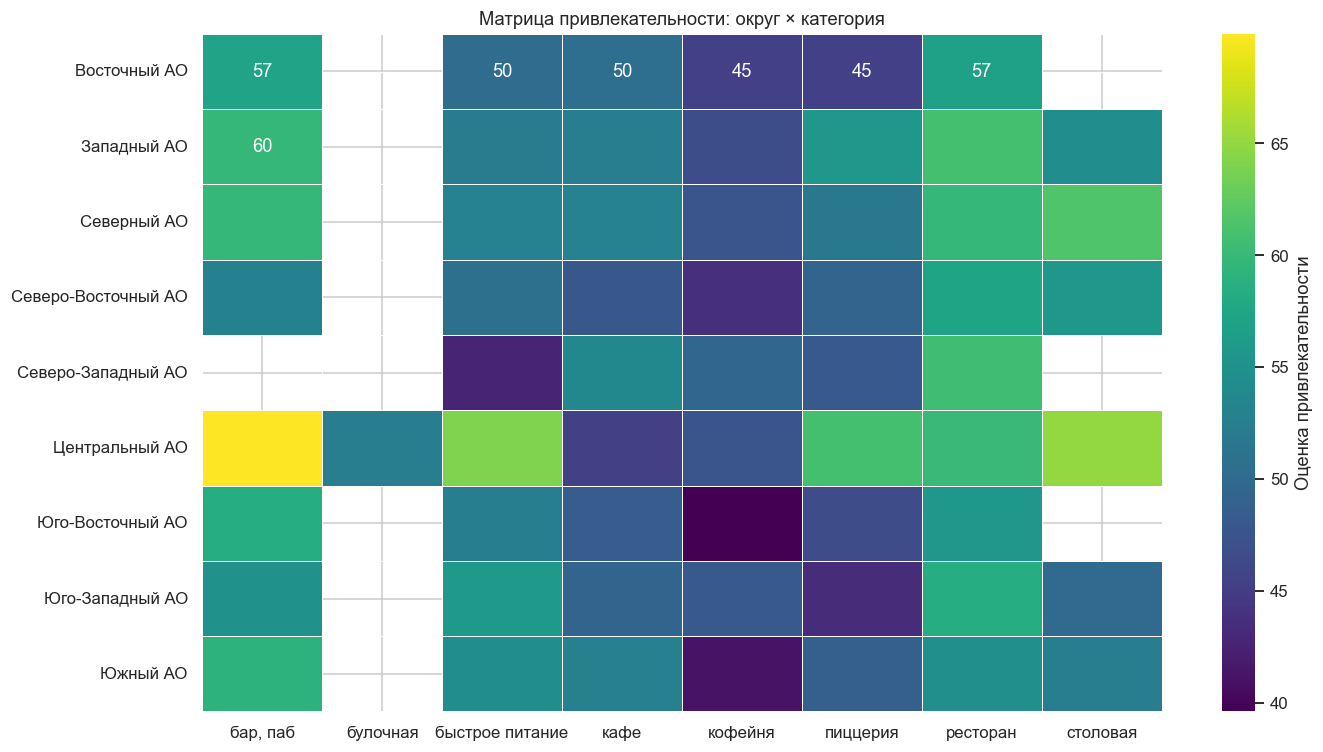

In [4]:
pivot = scores.pivot_table(index='district', columns='category', values='score')
pivot.index = pivot.index.str.replace(' административный округ', ' АО', regex=False)

fig, ax = plt.subplots(figsize=(13, 7))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='viridis', linewidths=.5,
            cbar_kws={'label': 'Оценка привлекательности'}, ax=ax)
ax.set(title='Матрица привлекательности: округ × категория', xlabel='', ylabel='')
plt.tight_layout()
plt.show()

## Разбор конкретной связки

Оценка бесполезна, если её нельзя объяснить. Раскладываем лидера на вклады
факторов — сумма вкладов и есть итоговый балл.

Центральный административный округ · бар, паб — оценка 69.9



,фактор,значение (0–1),вес,вклад в оценку
0,Свободность ниши,0.702,0.30,21.0
1,Потенциал выручки,0.694,0.25,17.4
2,Размер рынка округа,1.000,0.15,15.0
3,Фрагментированность,0.914,0.15,13.7
4,Слабость конкурентов,0.185,0.15,2.8


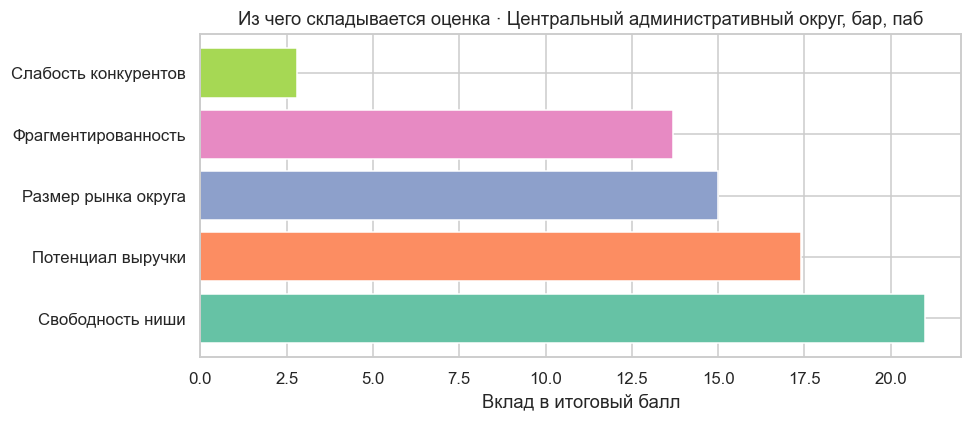

In [5]:
best = scores.iloc[0]
print(f'{best["district"]} · {best["category"]} — оценка {best["score"]}\n')
display(SC.explain(best))

fig, ax = plt.subplots(figsize=(9, 4))
e = SC.explain(best)
ax.barh(e['фактор'], e['вклад в оценку'], color=sns.color_palette('Set2'))
ax.set(title=f'Из чего складывается оценка · {best["district"]}, {best["category"]}',
       xlabel='Вклад в итоговый балл')
plt.tight_layout()
plt.show()

## Чувствительность к весам

Главный вопрос к любой такой модели: не подогнаны ли веса под желаемый ответ.
Проверяем три разных профиля инвестора и смотрим, что остаётся в топе при всех.

In [6]:
PROFILES = {
    'Осторожный (уходит от конкуренции)':
        {'competition': .50, 'revenue': .15, 'quality_gap': .10,
         'fragmentation': .15, 'traffic': .10},
    'Премиальный (идёт за чеком)':
        {'competition': .15, 'revenue': .50, 'quality_gap': .10,
         'fragmentation': .05, 'traffic': .20},
    'Масштабирующий (ищет трафик)':
        {'competition': .20, 'revenue': .15, 'quality_gap': .10,
         'fragmentation': .15, 'traffic': .40},
}

tops = {}
for name, w in PROFILES.items():
    s = SC.score(df, w)
    tops[name] = (s['district'].str.replace(' административный округ', ' АО', regex=False)
                  + ' · ' + s['category']).head(10).tolist()

display(pd.DataFrame(tops))

,Осторожный (уходит от конкуренции),Премиальный (идёт за чеком),Масштабирующий (ищет трафик)
0,Северный АО · столовая,Центральный АО · ресторан,"Центральный АО · бар, паб"
1,Центральный АО · столовая,"Центральный АО · бар, паб",Центральный АО · столовая
2,"Юго-Восточный АО · бар, паб",Центральный АО · пиццерия,Центральный АО · быстрое питание
3,"Западный АО · бар, паб",Западный АО · ресторан,Центральный АО · ресторан
4,"Центральный АО · бар, паб",Северный АО · ресторан,Центральный АО · пиццерия
5,Западный АО · столовая,Юго-Западный АО · ресторан,Центральный АО · булочная
6,"Южный АО · бар, паб",Восточный АО · ресторан,Центральный АО · кофейня
7,Северо-Западный АО · ресторан,Центральный АО · быстрое питание,Центральный АО · кафе
8,"Северный АО · бар, паб",Северо-Восточный АО · ресторан,Северный АО · столовая
9,Северо-Восточный АО · столовая,Северо-Западный АО · ресторан,"Северный АО · бар, паб"


In [7]:
sets = [set(v) for v in tops.values()]
stable = set.intersection(*sets)
print('Попадают в топ-10 при ВСЕХ трёх профилях инвестора:')
for s in sorted(stable):
    print('  •', s)
print(f'\nУстойчивых связок: {len(stable)} из 10')

Попадают в топ-10 при ВСЕХ трёх профилях инвестора:
  • Центральный АО · бар, паб

Устойчивых связок: 1 из 10


Устойчивое пересечение — и есть настоящая рекомендация. Связки, которые
всплывают только при одном наборе весов, — это свойство весов, а не рынка.

## Риск-профиль: оценка против насыщенности

Высокий балл при большой плотности заведений и высокий балл при пустом рынке —
разные истории. Первое означает «здесь есть спрос, но придётся драться»,
второе — «здесь свободно, но, возможно, не зря».

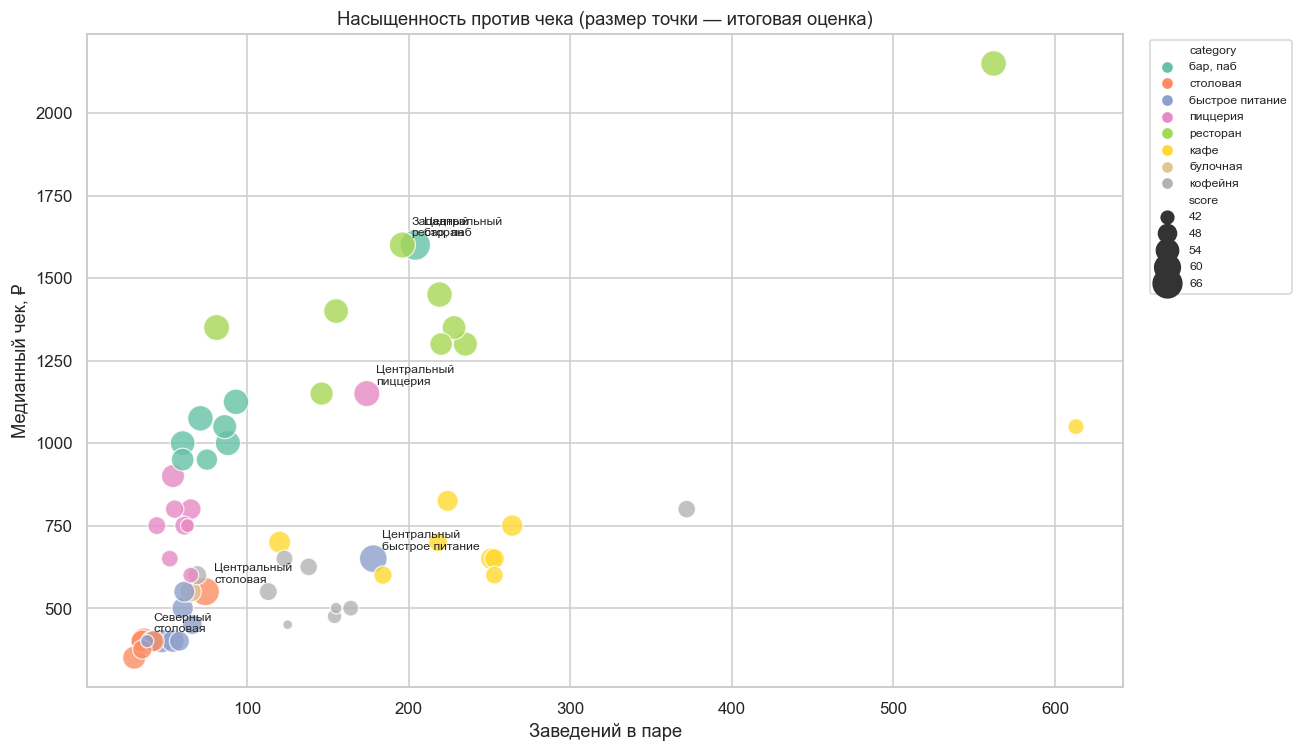

In [8]:
scores['label'] = (scores['district'].str.replace(' административный округ', '', regex=False)
                   + '\n' + scores['category'])
fig, ax = plt.subplots(figsize=(12, 7))
sns.scatterplot(data=scores, x='n', y='median_bill', size='score', hue='category',
                sizes=(40, 400), alpha=.8, palette='Set2', ax=ax)
for _, r in scores.head(6).iterrows():
    ax.annotate(r['label'], (r['n'], r['median_bill']), fontsize=8,
                xytext=(6, 6), textcoords='offset points')
ax.set(title='Насыщенность против чека (размер точки — итоговая оценка)',
       xlabel='Заведений в паре', ylabel='Медианный чек, ₽')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

## Ограничения модели

Честный список того, чего эта оценка не знает:

- **Нет данных об арендных ставках.** Свободная ниша в ЦАО может быть свободна
  именно потому, что аренда убивает экономику. Это главный пробел.
- **Нет трафика.** Число заведений в округе — грубый прокси; реальные потоки
  зависят от метро, офисов и жилой застройки, а не от границ округа.
- **Округ — слишком крупная единица.** Внутри ЦАО Тверская и Таганка — разные
  рынки. Нужен уровень района или, лучше, изохрон пешей доступности.
- **Данные статичны.** Нет динамики открытий и закрытий, а выживаемость точки
  информативнее их количества.
- **Веса — экспертные.** Они не выведены из данных, потому что в данных нет
  целевой переменной (выручки). Это оценочная модель, а не предсказательная.

Отсюда следующий шаг: связать датасет с данными об аренде и пассажиропотоке
метро — тогда оценку можно будет заменить моделью на реальном отклике.

→ **Интерактивная версия:** `streamlit run advanced/app/dashboard.py` —
там веса двигаются слайдерами, а результат пересчитывается на лету.